In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


MOUNT DATA TỪ GOOGLE DRIVE

THỐNG KÊ DỮ LIỆU

In [ ]:
import os

data_dir = '/content/drive/MyDrive/data_split/train'
if os.path.exists(data_dir):
    # Count only items that are directories
    num_folders = sum(1 for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item)))
    print(f'There are {num_folders} folders in {data_dir}')
else:
    print(f'Directory {data_dir} does not exist.')

data_dir = '/content/drive/MyDrive/data_split/test'
if os.path.exists(data_dir):
    # Count only items that are directories
    num_folders = sum(1 for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item)))
    print(f'There are {num_folders} folders in {data_dir}')
else:
    print(f'Directory {data_dir} does not exist.')

data_dir = '/content/drive/MyDrive/data_split/val'
if os.path.exists(data_dir):
    # Count only items that are directories
    num_folders = sum(1 for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item)))
    print(f'There are {num_folders} folders in {data_dir}')
else:
    print(f'Directory {data_dir} does not exist.')

There are 45 folders in /content/drive/MyDrive/data_split/train
There are 45 folders in /content/drive/MyDrive/data_split/test
There are 45 folders in /content/drive/MyDrive/data_split/val


XỬ LÝ DỮ LIỆU

THÊM CÁC THƯ VIỆN CẦN THIẾT ĐỂ TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
!pip install opencv-python

In [ ]:
!wget https://raw.githubusercontent.com/nagadomi/lbpcascade_animeface/master/lbpcascade_animeface.xml

--2026-05-06 09:54:33--  https://raw.githubusercontent.com/nagadomi/lbpcascade_animeface/master/lbpcascade_animeface.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 246945 (241K) [text/plain]
Saving to: ‘lbpcascade_animeface.xml’

lbpcascade_animefac 100%[===================>] 241.16K  --.-KB/s    in 0.003s  

2026-05-06 09:54:33 (86.9 MB/s) - ‘lbpcascade_animeface.xml’ saved [246945/246945]



In [ ]:
import cv2

face_cascade = cv2.CascadeClassifier("lbpcascade_animeface.xml")

1. Load & lọc ảnh
Bỏ ảnh lỗi (img is None)
Bỏ ảnh quá nhỏ
2. Detect face
Dùng MTCNN (khuyên dùng) hoặc DNN
Nếu nhiều mặt → chọn face lớn nhất
3. Crop + mở rộng
Crop theo bounding box
Expand ~20–30% để giữ tóc / viền

In [ ]:
import os
import cv2

def detect_and_crop(image_path, save_path):
    img = cv2.imread(image_path)

    if img is None:
        print(f"Bỏ qua file không đọc được: {image_path}")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(64, 64)
    )

    if len(faces) > 0:

        x, y, w, h = faces[0]

        expand_ratio = 0.3

        x1 = max(0, int(x - w*expand_ratio))
        y1 = max(0, int(y - h*expand_ratio))
        x2 = min(img.shape[1], int(x + w*(1+expand_ratio)))
        y2 = min(img.shape[0], int(y + h*(1+expand_ratio)))

        face = img[y1:y2, x1:x2]

        cv2.imwrite(save_path, face)

    else:

        cv2.imwrite(save_path, img)

In [ ]:
import os

# Ensure base_dataset_path and output_path are defined, as they were in previous cells
base_dataset_path = "/content/drive/MyDrive/data_split"
output_path = "/content/drive/MyDrive/faces_split"

# Process only the 'test' split
split = 'train'
split_path = os.path.join(base_dataset_path, split)

if not os.path.exists(split_path):
    print(f"Cảnh báo: Không tìm thấy thư mục {split_path}")
else:
    # Duyệt qua từng nhân vật trong split đó
    for character in os.listdir(split_path):
        char_path = os.path.join(split_path, character)

        # Tạo thư mục lưu trữ tương ứng: faces_split/test/ten_nhan_vat
        save_dir = os.path.join(output_path, split, character)
        os.makedirs(save_dir, exist_ok=True)

        if os.path.isdir(char_path):
            for img_name in os.listdir(char_path):
                img_path = os.path.join(char_path, img_name)
                save_path = os.path.join(save_dir, img_name)

                # Gọi hàm detect_and_crop đã định nghĩa ở trên
                detect_and_crop(img_path, save_path)

    print("Đã hoàn thành việc crop ảnh cho tập train!")

Đã hoàn thành việc crop ảnh cho tập train!


In [ ]:
import os

# Ensure base_dataset_path and output_path are defined, as they were in previous cells
base_dataset_path = "/content/drive/MyDrive/data_split"
output_path = "/content/drive/MyDrive/faces_split"

# Process only the 'test' split
split = 'val'
split_path = os.path.join(base_dataset_path, split)

if not os.path.exists(split_path):
    print(f"Cảnh báo: Không tìm thấy thư mục {split_path}")
else:
    # Duyệt qua từng nhân vật trong split đó
    for character in os.listdir(split_path):
        char_path = os.path.join(split_path, character)

        # Tạo thư mục lưu trữ tương ứng: faces_split/test/ten_nhan_vat
        save_dir = os.path.join(output_path, split, character)
        os.makedirs(save_dir, exist_ok=True)

        if os.path.isdir(char_path):
            for img_name in os.listdir(char_path):
                img_path = os.path.join(char_path, img_name)
                save_path = os.path.join(save_dir, img_name)

                # Gọi hàm detect_and_crop đã định nghĩa ở trên
                detect_and_crop(img_path, save_path)

    print("Đã hoàn thành việc crop ảnh cho tập validation!")

Đã hoàn thành việc crop ảnh cho tập validation!


THỐNG KÊ DỮ LIỆU CHO TẬP TRAIN

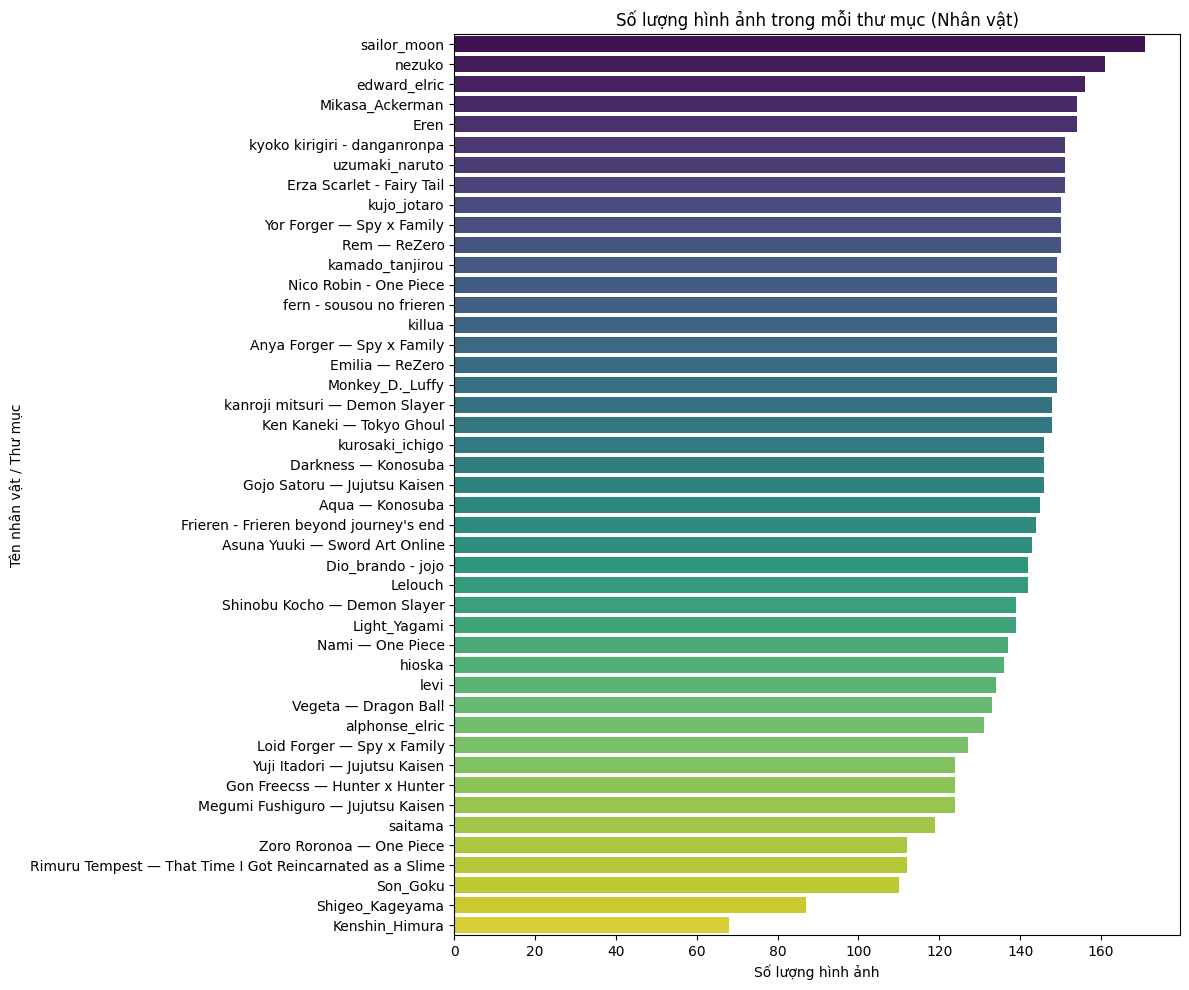

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '/content/drive/MyDrive/faces_split/train'
image_extensions = {'.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp'}
folder_counts = {}

if os.path.exists(data_dir):
    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)
        if os.path.isdir(folder_path):
            image_count = sum(
                1 for f in os.listdir(folder_path)
                if os.path.isfile(os.path.join(folder_path, f)) and os.path.splitext(f)[1].lower() in image_extensions
            )
            folder_counts[folder_name] = image_count

# Chuyển đổi dữ liệu thành DataFrame và sắp xếp
df_counts = pd.DataFrame(list(folder_counts.items()), columns=['Folder', 'Image_Count'])
df_counts = df_counts.sort_values(by='Image_Count', ascending=False)

# Cấu hình biểu đồ
plt.figure(figsize=(12, 10))
sns.barplot(x='Image_Count', y='Folder', data=df_counts, palette='viridis', hue='Folder', legend=False)
plt.title('Số lượng hình ảnh trong mỗi thư mục (Nhân vật)')
plt.xlabel('Số lượng hình ảnh')
plt.ylabel('Tên nhân vật / Thư mục')
plt.tight_layout()
plt.show()

THỐNG KÊ DỮ LIỆU CHO TẬP VALIDATION

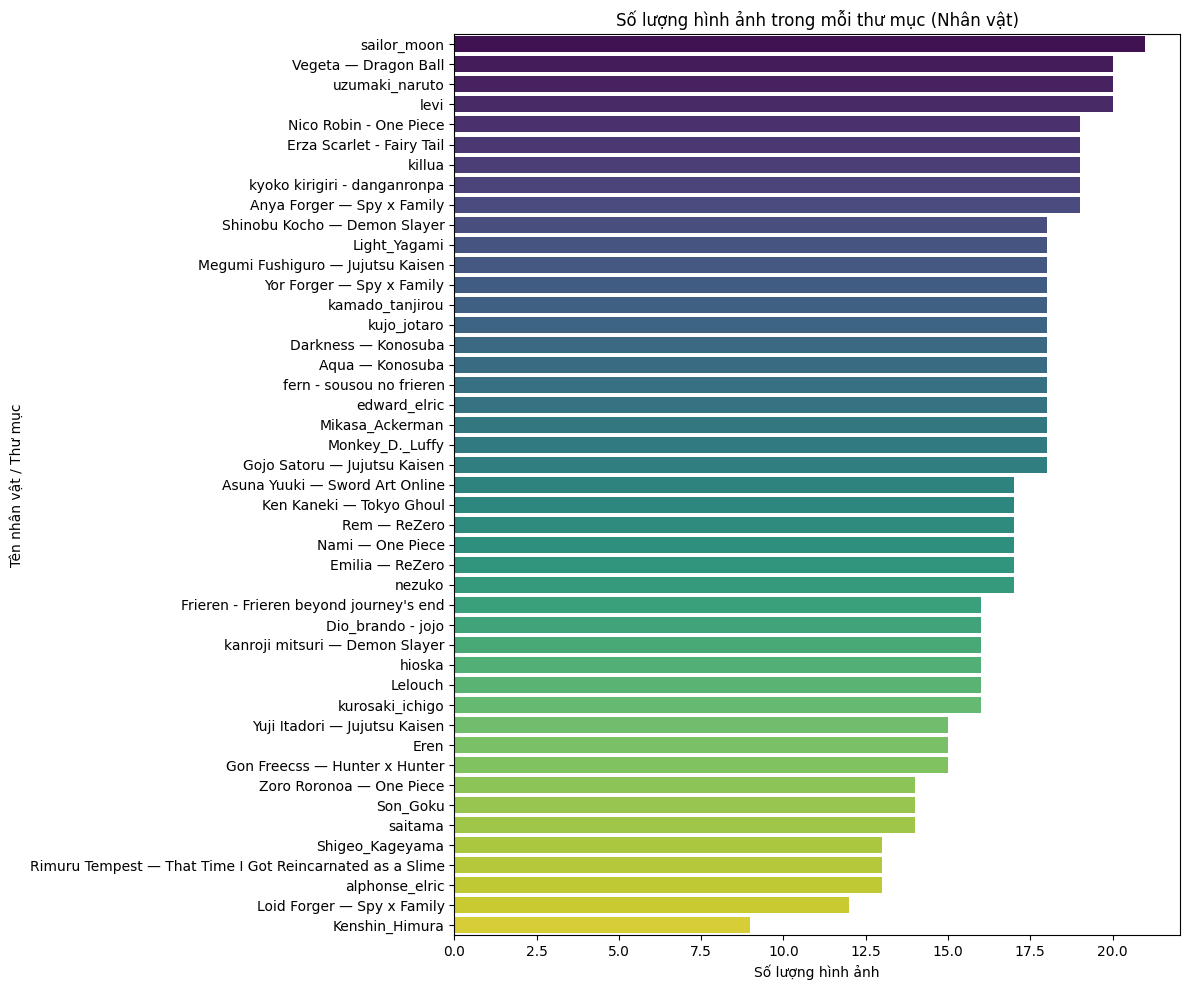

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '/content/drive/MyDrive/faces_split/val'
image_extensions = {'.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp'}
folder_counts = {}

if os.path.exists(data_dir):
    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)
        if os.path.isdir(folder_path):
            image_count = sum(
                1 for f in os.listdir(folder_path)
                if os.path.isfile(os.path.join(folder_path, f)) and os.path.splitext(f)[1].lower() in image_extensions
            )
            folder_counts[folder_name] = image_count

# Chuyển đổi dữ liệu thành DataFrame và sắp xếp
df_counts = pd.DataFrame(list(folder_counts.items()), columns=['Folder', 'Image_Count'])
df_counts = df_counts.sort_values(by='Image_Count', ascending=False)

# Cấu hình biểu đồ
plt.figure(figsize=(12, 10))
sns.barplot(x='Image_Count', y='Folder', data=df_counts, palette='viridis', hue='Folder', legend=False)
plt.title('Số lượng hình ảnh trong mỗi thư mục (Nhân vật)')
plt.xlabel('Số lượng hình ảnh')
plt.ylabel('Tên nhân vật / Thư mục')
plt.tight_layout()
plt.show()

TA CHỌN MÔ HÌNH VIT B-16 VÌ KÍCH THƯỚC VÀ HIỆU NĂNG CỦA NÓ SO VỚI CÁC MÔ HÌNH VIT TƯƠNG ĐỒNG KHÁC

TA BẮT ĐẦU TRAIN

Bước 1: sử dụng giá trị `recommended_num_workers_value` này để cấu hình `DataLoader` của mình

In [ ]:
import os

def get_recommended_num_workers():
    """
    Kiểm tra số lượng CPU cores và đưa ra đề xuất cho num_workers.
    """
    num_cpu_cores = os.cpu_count()
    if num_cpu_cores is not None:
        # Thường nên để num_workers bằng số lượng CPU cores hoặc ít hơn một chút
        # để tránh quá tải hệ thống, ví dụ: num_cpu_cores - 1 hoặc num_cpu_cores // 2
        # Tuy nhiên, 0 cũng là một lựa chọn nếu bạn gặp vấn đề.
        recommended_workers = min(8, num_cpu_cores - 1) if num_cpu_cores > 1 else 0
        print(f"Hệ thống của bạn có {num_cpu_cores} CPU cores.")
        print(f"Giá trị đề xuất cho num_workers là: {recommended_workers} (hoặc thử nghiệm với 0 để gỡ lỗi).")
        return recommended_workers
    else:
        print("Không thể xác định số lượng CPU cores. Đề xuất sử dụng num_workers=0 hoặc 2.")
        return 2

# Gọi hàm để kiểm tra và nhận đề xuất
recommended_num_workers_value = get_recommended_num_workers()


Hệ thống của bạn có 12 CPU cores.
Giá trị đề xuất cho num_workers là: 8 (hoặc thử nghiệm với 0 để gỡ lỗi).


Bước 2: Tạo các transform cho tập train và tập validation

In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(448, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((448,448)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

Bước 3: Tạo dataloader cho tập train và tập validation

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Đường dẫn đến thư mục chứa dữ liệu huấn luyện đã được cắt khuôn mặt
train_dir = 'drive/MyDrive/faces_split/train'

# Tạo Dataset sử dụng ImageFolder và áp dụng train_transform đã định nghĩa
train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transform # Sử dụng biến đổi đã định nghĩa
)

# Tạo DataLoader để tải dữ liệu theo từng batch trong quá trình huấn luyện
train_loader = DataLoader(
    train_dataset,
    batch_size=256, # Kích thước batch tùy chọn
    shuffle=True,  # Xáo trộn dữ liệu cho mỗi epoch
    num_workers=recommended_num_workers_value,  # Số lượng tiến trình con để tải dữ liệu (điều chỉnh tùy theo tài nguyên)
    pin_memory=True # Giúp tăng tốc độ truyền dữ liệu từ CPU lên GPU
)

print(f"Số lượng ảnh trong tập huấn luyện: {len(train_dataset)}")
print(f"Số lượng lớp (nhân vật): {len(train_dataset.classes)}")
print(f"Kích thước của một batch dữ liệu: {next(iter(train_loader))[0].shape}") # Ví dụ: [batch_size, channels, height, width]


Số lượng ảnh trong tập huấn luyện: 6219
Số lượng lớp (nhân vật): 45


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114821769 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Kích thước của một batch dữ liệu: torch.Size([256, 3, 448, 448])


In [ ]:
import os

# Đường dẫn đến thư mục chứa dữ liệu validation đã được cắt khuôn mặt
# Assuming '/content/drive/MyDrive/faces_split/val' still contains data after previous processing.
val_dir = '/content/drive/MyDrive/faces_split/val'

# Tạo Dataset sử dụng ImageFolder và áp dụng val_transform
val_dataset = ImageFolder(
    root=val_dir,
    transform=val_transform # Sử dụng biến đổi đã định nghĩa cho validation
)

# Tạo DataLoader cho tập validation
val_loader = DataLoader(
    val_dataset,
    batch_size=256, # Kích thước batch tùy chọn, có thể giống train
    shuffle=False, # Không cần xáo trộn dữ liệu validation
    num_workers=recommended_num_workers_value,  # Số lượng tiến trình con để tải dữ liệu
    pin_memory=True # Giúp tăng tốc độ truyền dữ liệu từ CPU lên GPU
)

print(f"Số lượng ảnh trong tập validation: {len(val_dataset)}")
print(f"Kích thước của một batch dữ liệu validation: {next(iter(val_loader))[0].shape}")


Số lượng ảnh trong tập validation: 755
Kích thước của một batch dữ liệu validation: torch.Size([256, 3, 448, 448])


Bước 4: Setup GPU cho quá trình huấn luyện

In [ ]:
import torch

# 1. Kiểm tra xem có GPU (CUDA) khả dụng hay không
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang được sử dụng: {device}")

if device.type == 'cuda':
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
    print(f"Số lượng GPU: {torch.cuda.device_count()}")


Thiết bị đang được sử dụng: cuda
Tên GPU: NVIDIA A100-SXM4-80GB
Số lượng GPU: 1


Bước 4: Cài đặt thư viện `transformers` của Hugging Face, cần thiết để tải và làm việc với các mô hình đã huấn luyện trước.


In [ ]:
import sys
!{sys.executable} -m pip install transformers

Bước 5: Tải mô hình Vision Transformer (ViT) đã huấn luyện trước từ `SmilingWolf/wd-vit-tagger-v3` sử dụng `AutoModelForImageClassification` hoặc `ViTForImageClassification` từ thư viện `transformers`. Đồng thời, tải bộ xử lý (processor) tương ứng nếu có.


In [ ]:
!pip install timm

In [ ]:
from transformers import AutoModelForImageClassification, AutoProcessor

# Define the pre-trained model name
model_name = 'SmilingWolf/wd-vit-tagger-v3'

# Load the pre-trained processor
processor = AutoProcessor.from_pretrained(model_name)
print(f"Loaded processor from: {model_name}")

# Load the pre-trained Vision Transformer model for image classification
model = AutoModelForImageClassification.from_pretrained(model_name)
print(f"Loaded model from: {model_name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

Loaded processor from: SmilingWolf/wd-vit-tagger-v3


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loaded model from: SmilingWolf/wd-vit-tagger-v3


Bước 6: Chuyển model sang device: cuda


In [ ]:
model.to(device)
print(f"Model moved to {device}")

Model moved to cuda


In [ ]:
print(model)

TimmWrapperForImageClassification(
  (timm_model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=307

Bước 7: Thay đổi lớp classifier của model để phù hợp với vấn đề mà ta cần phải giải quyết


In [ ]:
import torch.nn as nn

# 1. Get the number of classes from train_dataset
num_classes = len(train_dataset.classes)
print(f"Số lượng lớp tùy chỉnh: {num_classes}")

# 2. Identify and get in_features from the original classification head
# From the model structure, the head is model.timm_model.head
original_in_features = model.timm_model.head.in_features
print(f"Số lượng in_features gốc của lớp head: {original_in_features}")

# 3. Replace the classification head
model.timm_model.head = nn.Linear(original_in_features, num_classes)
print("Đã thay thế lớp phân loại cuối cùng của mô hình.")

# 4. Move the modified model back to the device
model.to(device)
print(f"Mô hình đã được di chuyển đến: {device}")
print(train_dataset.class_to_idx)


Số lượng lớp tùy chỉnh: 45
Số lượng in_features gốc của lớp head: 768
Đã thay thế lớp phân loại cuối cùng của mô hình.
Mô hình đã được di chuyển đến: cuda
{'Anya Forger — Spy x Family': 0, 'Aqua — Konosuba': 1, 'Asuna Yuuki — Sword Art Online': 2, 'Darkness — Konosuba': 3, 'Dio_brando - jojo': 4, 'Emilia — ReZero': 5, 'Eren': 6, 'Erza Scarlet - Fairy Tail': 7, "Frieren - Frieren beyond journey's end": 8, 'Gojo Satoru — Jujutsu Kaisen': 9, 'Gon Freecss — Hunter x Hunter': 10, 'Ken Kaneki — Tokyo Ghoul': 11, 'Kenshin_Himura': 12, 'Lelouch': 13, 'Light_Yagami': 14, 'Loid Forger — Spy x Family': 15, 'Megumi Fushiguro — Jujutsu Kaisen': 16, 'Mikasa_Ackerman': 17, 'Monkey_D._Luffy': 18, 'Nami — One Piece': 19, 'Nico Robin - One Piece': 20, 'Rem — ReZero': 21, 'Rimuru Tempest — That Time I Got Reincarnated as a Slime': 22, 'Shigeo_Kageyama': 23, 'Shinobu Kocho — Demon Slayer': 24, 'Son_Goku': 25, 'Vegeta — Dragon Ball': 26, 'Yor Forger — Spy x Family': 27, 'Yuji Itadori — Jujutsu Kaisen': 28,

Bước 8: Sử dụng transfer learning và freeze những tham số từ các layer trước ngoại trừ layer classifier

In [ ]:
# Freeze tất cả các tham số trong backbone của mô hình
# (tức là tất cả các tham số ngoại trừ lớp head đã được thay thế)
for name, param in model.named_parameters():
    if 'head' not in name: # Giả định lớp head đã được thay thế và là phần duy nhất cần được huấn luyện
        param.requires_grad = False
    else:
        param.requires_grad = True # Đảm bảo lớp head vẫn được huấn luyện

# Kiểm tra xem các tham số đã được đóng băng thành công hay chưa
print("Kiểm tra trạng thái requires_grad của các tham số:")
for name, param in model.named_parameters():
    print(f"Parameter: {name}, requires_grad: {param.requires_grad}")

print("\nBackbone của mô hình đã được đóng băng. Chỉ lớp phân loại cuối cùng (head) là có thể huấn luyện.")

Kiểm tra trạng thái requires_grad của các tham số:
Parameter: timm_model.pos_embed, requires_grad: False
Parameter: timm_model.patch_embed.proj.weight, requires_grad: False
Parameter: timm_model.patch_embed.proj.bias, requires_grad: False
Parameter: timm_model.blocks.0.norm1.weight, requires_grad: False
Parameter: timm_model.blocks.0.norm1.bias, requires_grad: False
Parameter: timm_model.blocks.0.attn.qkv.weight, requires_grad: False
Parameter: timm_model.blocks.0.attn.qkv.bias, requires_grad: False
Parameter: timm_model.blocks.0.attn.proj.weight, requires_grad: False
Parameter: timm_model.blocks.0.attn.proj.bias, requires_grad: False
Parameter: timm_model.blocks.0.norm2.weight, requires_grad: False
Parameter: timm_model.blocks.0.norm2.bias, requires_grad: False
Parameter: timm_model.blocks.0.mlp.fc1.weight, requires_grad: False
Parameter: timm_model.blocks.0.mlp.fc1.bias, requires_grad: False
Parameter: timm_model.blocks.0.mlp.fc2.weight, requires_grad: False
Parameter: timm_model.blo

Bước 9: Xây dựng hàm train

In [ ]:
import torch
from tqdm.auto import tqdm
from typing import Tuple, Dict, List
import copy # Import copy module to deepcopy the best model state
import torch.amp as amp # Import for Automatic Mixed Precision (updated for future warning)

def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: amp.GradScaler # Pass the scaler
) -> Tuple[float, float]:
    """
    Performs a single training step (forward, backward, optimize) for one epoch.
    Includes Automatic Mixed Precision (AMP) for A100.
    """
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    # Iterate through data_loader with tqdm for visualizable progress
    for X, y in tqdm(data_loader, desc="Training"): # Added desc for clarity
        # Use non_blocking for faster transfer if pin_memory=True
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Forward pass with Automatic Mixed Precision
        with amp.autocast(device_type='cuda'): # Updated for future warning
            y_pred = model(X)
            # FIX: Access the .logits attribute from the model output
            loss = loss_fn(y_pred.logits, y)

        # Backward pass and optimize with gradient scaling
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate loss
        train_loss += loss.item()

        # Compute accuracy
        predicted = y_pred.logits.argmax(dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    # Calculate average loss and accuracy for the epoch
    avg_train_loss = train_loss / len(data_loader)
    avg_train_acc = correct / total

    return avg_train_loss, avg_train_acc
def validation_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """
    Performs a single validation step (forward pass) for one epoch.
    """
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad(): # Tắt tính toán gradient cho validation
        for X, y in tqdm(data_loader, desc="Validation"): # Added desc for clarity
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            # Forward pass
            y_pred = model(X)
            loss = loss_fn(y_pred.logits, y)

            # Accumulate loss
            val_loss += loss.item()

            # Compute accuracy
            predicted = y_pred.logits.argmax(dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    # Calculate average loss and accuracy for the epoch
    avg_val_loss = val_loss / len(data_loader)
    avg_val_acc = correct / total

    return avg_val_loss, avg_val_acc

def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader, # Added val_dataloader parameter
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device,
    patience: int = 5, # Added patience parameter for early stopping
    model_save_path: str = "best_model.pth" # Path to save the best model
) -> Dict[str, List]:
    """
    Trains a PyTorch model for a number of epochs with early stopping.

    Args:
        model: The PyTorch model to be trained.
        train_dataloader: DataLoader for the training data.
        val_dataloader: DataLoader for the validation data.
        optimizer: The optimizer used for training.
        loss_fn: The loss function used for training.
        epochs: The number of epochs to train for.
        device: The device to train on (e.g., "cuda" or "cpu").
        patience: Number of epochs to wait for improvement before early stopping.
        model_save_path: File path to save the best model.

    Returns:
        A dictionary of training and validation loss and accuracy metrics for each epoch.
    """

    # Initialize GradScaler for mixed precision training
    scaler = amp.GradScaler(device='cuda') # Updated for future warning

    # Create empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [], # Added val_loss
        "val_acc": []   # Added val_acc
    }

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict()) # To save the best model weights

    for epoch in range(epochs):
        print(f"Epoch: {epoch + 1}/{epochs}")
        train_loss, train_acc = train_step(
            model=model,
            data_loader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
            scaler=scaler # Pass the scaler to train_step
        )

        val_loss, val_acc = validation_step(
            model=model,
            data_loader=val_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        # Print and store results
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict()) # Save best model weights
            torch.save(model.state_dict(), model_save_path)
            print(f"  Validation loss improved. Model saved to {model_save_path}")
        else:
            epochs_no_improve += 1
            print(f"  Validation loss did not improve for {epochs_no_improve} epoch(s).")
            if epochs_no_improve == patience:
                print(f"  Early stopping triggered after {patience} epochs without improvement.")
                model.load_state_dict(best_model_wts) # Load best model weights
                break

    model.load_state_dict(best_model_wts) # Ensure the best model weights are loaded after training
    return results

Bước 10: Tiến hành quá trình train và ghi nhận

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa hàm mất mát (Loss Function)
# CrossEntropyLoss phù hợp cho bài toán phân loại đa lớp
loss_fn = nn.CrossEntropyLoss()
print("Đã định nghĩa hàm mất mát: CrossEntropyLoss")

# 2. Định nghĩa bộ tối ưu hóa (Optimizer)
# Chỉ truyền các tham số cần huấn luyện (requires_grad=True) vào optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5) # lr là learning rate, có thể điều chỉnh
print("Đã định nghĩa bộ tối ưu hóa: Adam")

# 3. Định nghĩa số lượng epoch và patience cho early stopping
epochs = 30 # Tăng số epoch tối đa
patience = 5 # Số epoch chờ nếu val_loss không cải thiện
model_save_path = "/content/drive/MyDrive/best_vit_model.pth" # Đường dẫn lưu model tốt nhất
print(f"Số lượng epoch huấn luyện tối đa: {epochs}")
print(f"Patience cho Early Stopping: {patience}")
print(f"Model tốt nhất sẽ được lưu tại: {model_save_path}")

# 4. Bắt đầu huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader, # Truyền val_loader vào hàm train
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=device,
    patience=patience,
    model_save_path=model_save_path
)

print("\nQuá trình huấn luyện đã hoàn tất!")

Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30


Training:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114715602 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (109111387 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Train Loss: 3.5840 | Train Acc: 0.1124 | Val Loss: 3.5685 | Val Acc: 0.1351
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth
Epoch: 2/30


...

Training:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119191392 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dec16d54e00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^

Validation:   0%|          | 0/3 [00:13<?, ?it/s]

^^^^^^^^
AssertionError: can only test a child process


RuntimeError: DataLoader worker (pid 47168) is killed by signal: Aborted. 

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa hàm mất mát (Loss Function)
# CrossEntropyLoss phù hợp cho bài toán phân loại đa lớp
loss_fn = nn.CrossEntropyLoss()
print("Đã định nghĩa hàm mất mát: CrossEntropyLoss")

# 2. Định nghĩa bộ tối ưu hóa (Optimizer)
# Chỉ truyền các tham số cần huấn luyện (requires_grad=True) vào optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5) # lr là learning rate, có thể điều chỉnh
print("Đã định nghĩa bộ tối ưu hóa: Adam")

# 3. Định nghĩa số lượng epoch và patience cho early stopping
epochs = 30 # Tăng số epoch tối đa
patience = 5 # Số epoch chờ nếu val_loss không cải thiện
model_save_path = "/content/drive/MyDrive/best_vit_model.pth" # Đường dẫn lưu model tốt nhất
print(f"Số lượng epoch huấn luyện tối đa: {epochs}")
print(f"Patience cho Early Stopping: {patience}")
print(f"Model tốt nhất sẽ được lưu tại: {model_save_path}")

# 4. Bắt đầu huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader, # Truyền val_loader vào hàm train
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=device,
    patience=patience,
    model_save_path=model_save_path
)

print("\nQuá trình huấn luyện đã hoàn tất!")


"""

Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30


Training:   0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

"""
=== TRAINING LOGS ===
Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30
Training: 100% 25/25 [02:20<00:00, 1.27s/it]
Validation: 100% 3/3 [00:23<00:00, 5.92s/it]
Train Loss: 3.1074 | Train Acc: 0.3636 | Val Loss: 2.9853 | Val Acc: 0.4053
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth

Epoch: 2/30
Training: 100% 25/25 [01:51<00:00, 1.08s/it]
Validation: 100% 3/3 [00:22<00:00, 5.84s/it]
Train Loss: 2.8160 | Train Acc: 0.4985 | Val Loss: 2.6645 | Val Acc: 0.5377
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth

Epoch: 3/30
Training: 100% 25/25 [01:53<00:00, 1.04s/it]
Validation: 0% 0/3 [00:05<?, ?it/s]
RuntimeError: DataLoader worker (pid(s) 15025) exited unexpectedly

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa hàm mất mát (Loss Function)
# CrossEntropyLoss phù hợp cho bài toán phân loại đa lớp
loss_fn = nn.CrossEntropyLoss()
print("Đã định nghĩa hàm mất mát: CrossEntropyLoss")

# 2. Định nghĩa bộ tối ưu hóa (Optimizer)
# Chỉ truyền các tham số cần huấn luyện (requires_grad=True) vào optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5) # lr là learning rate, có thể điều chỉnh
print("Đã định nghĩa bộ tối ưu hóa: Adam")

# 3. Định nghĩa số lượng epoch và patience cho early stopping
epochs = 30 # Tăng số epoch tối đa
patience = 5 # Số epoch chờ nếu val_loss không cải thiện
model_save_path = "/content/drive/MyDrive/best_vit_model.pth" # Đường dẫn lưu model tốt nhất
print(f"Số lượng epoch huấn luyện tối đa: {epochs}")
print(f"Patience cho Early Stopping: {patience}")
print(f"Model tốt nhất sẽ được lưu tại: {model_save_path}")

# 4. Bắt đầu huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader, # Truyền val_loader vào hàm train
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=device,
    patience=patience,
    model_save_path=model_save_path
)

print("\nQuá trình huấn luyện đã hoàn tất!")

Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30


Training:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (110615456 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114082512 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78077d87e980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78077d87e980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78077d87e980>
<function _MultiProcessingDataLoaderIter.__del__ at 0x78077d87e980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x78077d87e980>self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in 

Training:   0%|          | 0/25 [00:01<?, ?it/s]

^^   ^^^ ^^^^^^^^^^^^^^^^^^^^^^^^

RuntimeError: DataLoader worker (pid 29856) is killed by signal: Aborted. 

^^^^^^^^^^^^^^
^^^^AssertionError^: ^can only test a child process^
^^^^^^^^^

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa hàm mất mát (Loss Function)
# CrossEntropyLoss phù hợp cho bài toán phân loại đa lớp
loss_fn = nn.CrossEntropyLoss()
print("Đã định nghĩa hàm mất mát: CrossEntropyLoss")

# 2. Định nghĩa bộ tối ưu hóa (Optimizer)
# Chỉ truyền các tham số cần huấn luyện (requires_grad=True) vào optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5) # lr là learning rate, có thể điều chỉnh
print("Đã định nghĩa bộ tối ưu hóa: Adam")

# 3. Định nghĩa số lượng epoch và patience cho early stopping
epochs = 30 # Tăng số epoch tối đa
patience = 5 # Số epoch chờ nếu val_loss không cải thiện
model_save_path = "/content/drive/MyDrive/best_vit_model.pth" # Đường dẫn lưu model tốt nhất
print(f"Số lượng epoch huấn luyện tối đa: {epochs}")
print(f"Patience cho Early Stopping: {patience}")
print(f"Model tốt nhất sẽ được lưu tại: {model_save_path}")

# 4. Bắt đầu huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader, # Truyền val_loader vào hàm train
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=device,
    patience=patience,
    model_save_path=model_save_path
)

print("\nQuá trình huấn luyện đã hoàn tất!")

Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30


Training:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (115152849 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (119238210 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Train Loss: 0.2615 | Train Acc: 0.9539 | Val Loss: 0.3211 | Val Acc: 0.9298
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth
Epoch: 2/30


...

Train Loss: 0.0962 | Train Acc: 0.9818 | Val Loss: 0.2159 | Val Acc: 0.9523
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth
Epoch: 9/30


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a15d1346ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a15d1346ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Training:   0%|          | 0/25 [00:03<?, ?it/s]

^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Traceback (most recent call last):
Exception in thread Traceback (most recent call last):
Exception in thread Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
QueueFeederThread  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
QueueFeederThread  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
:
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
   

RuntimeError: DataLoader worker (pid 12679) is killed by signal: Aborted. 

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa hàm mất mát (Loss Function)
# CrossEntropyLoss phù hợp cho bài toán phân loại đa lớp
loss_fn = nn.CrossEntropyLoss()
print("Đã định nghĩa hàm mất mát: CrossEntropyLoss")

# 2. Định nghĩa bộ tối ưu hóa (Optimizer)
# Chỉ truyền các tham số cần huấn luyện (requires_grad=True) vào optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5) # lr là learning rate, có thể điều chỉnh
print("Đã định nghĩa bộ tối ưu hóa: Adam")

# 3. Định nghĩa số lượng epoch và patience cho early stopping
epochs = 30 # Tăng số epoch tối đa
patience = 5 # Số epoch chờ nếu val_loss không cải thiện
model_save_path = "/content/drive/MyDrive/best_vit_model.pth" # Đường dẫn lưu model tốt nhất
print(f"Số lượng epoch huấn luyện tối đa: {epochs}")
print(f"Patience cho Early Stopping: {patience}")
print(f"Model tốt nhất sẽ được lưu tại: {model_save_path}")

# 4. Bắt đầu huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
results = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader, # Truyền val_loader vào hàm train
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=device,
    patience=patience,
    model_save_path=model_save_path
)

print("\nQuá trình huấn luyện đã hoàn tất!")

Đã định nghĩa hàm mất mát: CrossEntropyLoss
Đã định nghĩa bộ tối ưu hóa: Adam
Số lượng epoch huấn luyện tối đa: 30
Patience cho Early Stopping: 5
Model tốt nhất sẽ được lưu tại: /content/drive/MyDrive/best_vit_model.pth

Bắt đầu huấn luyện mô hình...
Epoch: 1/30


Training:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114852969 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (127788870 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Train Loss: 0.0878 | Train Acc: 0.9841 | Val Loss: 0.2134 | Val Acc: 0.9523
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth
Epoch: 2/30


...

Train Loss: 0.0860 | Train Acc: 0.9850 | Val Loss: 0.2091 | Val Acc: 0.9523
  Validation loss improved. Model saved to /content/drive/MyDrive/best_vit_model.pth
Epoch: 5/30


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aed6da26ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aed6da26ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Training:   0%|          | 0/25 [00:02<?, ?it/s]


Exception in thread Exception in thread Traceback (most recent call last):
Exception in thread Traceback (most recent call last):
Traceback (most recent call last):
QueueFeederThreadTraceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
QueueFeederThread  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
QueueFeederThread  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
:
:
:
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in 

RuntimeError: DataLoader worker (pid 9638) is killed by signal: Aborted. 

Bước 11: plot train, validation loss và accuracy

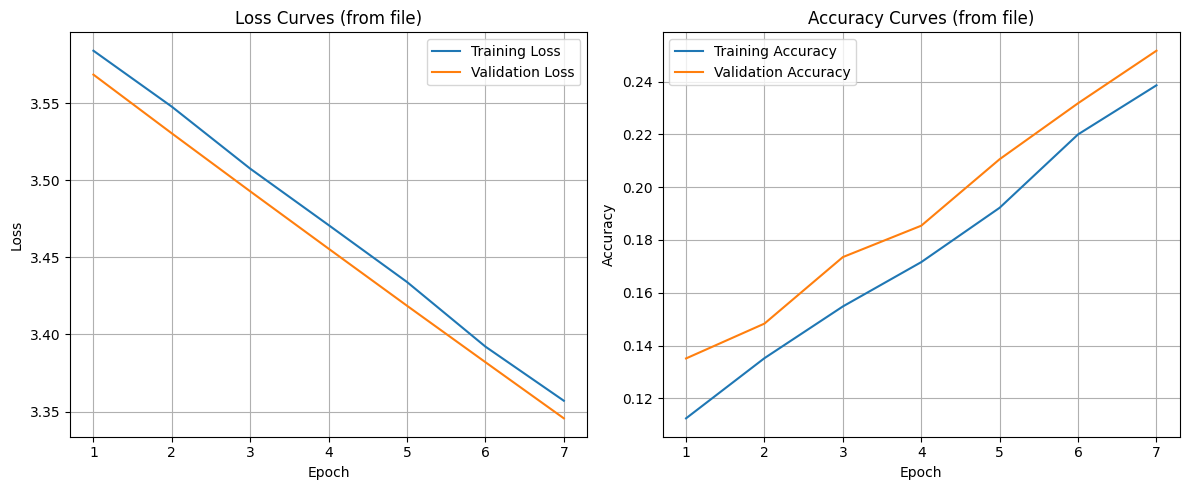

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import io # To read the string content as a file

log_file_path = '/content/drive/MyDrive/training_metrics.txt'

try:
    # Read the content of the file
    with open(log_file_path, 'r') as f:
        file_content = f.read()

    # Use io.StringIO to treat the string content as a file
    # read_csv can handle tab-separated values by default, but we'll explicitly set sep
    df_metrics = pd.read_csv(io.StringIO(file_content), sep='\t', engine='python')

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(df_metrics['Epoch'], df_metrics['Train Loss'], label='Training Loss')
    plt.plot(df_metrics['Epoch'], df_metrics['Val Loss'], label='Validation Loss')
    plt.title('Loss Curves (from file)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(df_metrics['Epoch'], df_metrics['Train Acc'], label='Training Accuracy')
    plt.plot(df_metrics['Epoch'], df_metrics['Val Acc'], label='Validation Accuracy')
    plt.title('Accuracy Curves (from file)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print(f"Error: Log file not found at {log_file_path}. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while parsing or plotting the log file: {e}")


In [ ]:
import os
import cv2
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix


def preprocess_face_for_vit(face_crop, device, val_transform=None, processor=None):
    """
    Convert a cropped OpenCV face (BGR) into model-ready tensors for ViT.

    Priority:
    1) val_transform (if provided)
    2) processor (fallback)
    """
    # Convert BGR (OpenCV) -> RGB -> PIL
    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    face_pil = Image.fromarray(face_rgb)

    # Use user-defined test/validation transform first
    if val_transform is not None:
        pixel_values = val_transform(face_pil).unsqueeze(0).to(device)
        return {'pixel_values': pixel_values}

    # Fallback to Hugging Face processor
    if processor is not None:
        inputs = processor(images=face_pil, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        return inputs

    raise ValueError('Either val_transform or processor must be provided.')


def predict_image_cascade_vit(image_path, cascade, vit_model, device, train_dataset,
                              val_transform=None, processor=None,
                              scale_factor=1.1, min_neighbors=5, min_size=(64, 64),
                              verbose=True):
    """
    Pipeline: Cascade Classifier Detection -> Test Transform/Processor -> ViT Classification

    If no faces are detected, the full original image is used as the input to the ViT model.

    Args:
        image_path: path to input image
        cascade: OpenCV CascadeClassifier object
        vit_model: ViT classification model
        device: torch device
        train_dataset: dataset with class names
        val_transform: torchvision transform for test/validation preprocessing
        processor: ViT processor (Hugging Face), used as fallback when val_transform is None
        scale_factor, min_neighbors, min_size: cascade parameters
        verbose: whether to print per-image debug output

    Returns:
        List of predictions: [{'class_name': str, 'confidence': float, 'bbox': (x, y, w, h)}]
    """

    # Load image
    image_cv = cv2.imread(image_path)
    if image_cv is None:
        if verbose:
            print(f'Error: Cannot read image from {image_path}')
        return []

    # Convert to grayscale for cascade detection
    gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

    # Detect faces with cascade classifier
    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    predictions = []

    if verbose:
        print(f'Image: {image_path}')
        print(f'Found {len(faces)} faces')

    if len(faces) == 0:
        # No face detected - use the full image as input
        if verbose:
            print('No faces detected - running ViT on the full image.')
        h_full, w_full = image_cv.shape[:2]
        face_crops = [(image_cv, (0, 0, w_full, h_full))]
    else:
        face_crops = [(image_cv[y:y+h, x:x+w], (x, y, w, h)) for x, y, w, h in faces]

    # Process each crop (detected face or full image)
    for idx, (face_crop, bbox) in enumerate(face_crops):
        x, y, w, h = bbox

        if face_crop.size == 0:
            if verbose:
                print(f'  Face {idx}: Invalid crop, skipping')
            continue

        try:
            # Explicit test preprocessing step (val_transform first)
            inputs = preprocess_face_for_vit(
                face_crop,
                device=device,
                val_transform=val_transform,
                processor=processor
            )

            # ViT inference
            with torch.no_grad():
                outputs = vit_model(**inputs)
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1)
                class_idx = logits.argmax(dim=1).item()
                confidence = probs[0, class_idx].item()

            class_name = train_dataset.classes[class_idx]

            predictions.append({
                'class_name': class_name,
                'confidence': float(confidence),
                'bbox': (x, y, w, h)
            })

            if verbose:
                print(f'  Face {idx}: {class_name} ({confidence:.2%})')

        except Exception as e:
            if verbose:
                print(f'  Face {idx}: Error processing - {str(e)}')
            continue

    return predictions


def evaluate_cascade_vit_on_folder(test_root, cascade, vit_model, device, train_dataset,
                                   val_transform=None, processor=None,
                                   image_extensions=('.jpg', '.jpeg', '.png', '.bmp', '.webp'),
                                   verbose=False):
    """
    Evaluate the cascade+ViT pipeline on a folder structured like train/
    (one subfolder per class) and return accuracy + classification metrics.
    """
    if not os.path.isdir(test_root):
        raise FileNotFoundError(f'Test folder not found: {test_root}')

    valid_classes = set(train_dataset.classes)
    y_true = []
    y_pred = []
    per_class_counts = {}
    skipped_files = 0

    for class_name in sorted(os.listdir(test_root)):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue

        if class_name not in valid_classes:
            print(f"Skipping unknown class folder not in train_dataset: {class_name}")
            continue

        image_files = [
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f))
            and f.lower().endswith(image_extensions)
        ]
        per_class_counts[class_name] = len(image_files)

        for image_name in image_files:
            image_path = os.path.join(class_dir, image_name)

            preds = predict_image_cascade_vit(
                image_path=image_path,
                cascade=cascade,
                vit_model=vit_model,
                device=device,
                train_dataset=train_dataset,
                val_transform=val_transform,
                processor=processor,
                verbose=verbose
            )

            if preds:
                # Use the most confident prediction if multiple faces are detected
                best_pred = max(preds, key=lambda p: p['confidence'])['class_name']
            else:
                # If prediction fails completely, count as a wrong prediction token
                best_pred = '__no_prediction__'
                skipped_files += 1

            y_true.append(class_name)
            y_pred.append(best_pred)

    if not y_true:
        raise ValueError('No valid test images found to evaluate.')

    # Overall accuracy counts failed predictions as incorrect
    accuracy = accuracy_score(y_true, y_pred)

    # Macro metrics over known classes only
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=train_dataset.classes,
        average='macro',
        zero_division=0
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=train_dataset.classes,
        target_names=train_dataset.classes,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=train_dataset.classes)

    return {
        'num_images': len(y_true),
        'num_failed_predictions': skipped_files,
        'accuracy': float(accuracy),
        'precision_macro': float(precision),
        'recall_macro': float(recall),
        'f1_macro': float(f1),
        'classification_report': report,
        'confusion_matrix': cm,
        'class_order': train_dataset.classes,
        'per_class_counts': per_class_counts
    }

In [ ]:
# Evaluate on a test folder that has the same structure as train/
import os

print("=" * 70)
print("CASCADE CLASSIFIER + VIT EVALUATION ON TEST FOLDER")
print("=" * 70)

# Update this path to your test split root folder
test_folder_path = "/content/drive/MyDrive/faces_split/test"

try:
    if not os.path.isdir(test_folder_path):
        raise FileNotFoundError(test_folder_path)

    metrics = evaluate_cascade_vit_on_folder(
        test_root=test_folder_path,
        cascade=face_cascade,
        vit_model=model,
        device=device,
        train_dataset=train_dataset,
        val_transform=val_transform,
        processor=processor,
        verbose=False  # set True for per-image logs
    )

    print(f"\nTotal evaluated images: {metrics['num_images']}")
    print(f"Failed predictions: {metrics['num_failed_predictions']}")
    print(f"Accuracy       : {metrics['accuracy']:.4f}")
    print(f"PrecisionMacro : {metrics['precision_macro']:.4f}")
    print(f"RecallMacro    : {metrics['recall_macro']:.4f}")
    print(f"F1Macro        : {metrics['f1_macro']:.4f}")

    print("\nClassification report:")
    print(metrics['classification_report'])

    # Optional: inspect confusion matrix
    print("Confusion matrix shape:", metrics['confusion_matrix'].shape)

except FileNotFoundError:
    print(f"Test folder not found: {test_folder_path}")
    print("Please update test_folder_path to your test split root")
except NameError as e:
    print(f"Missing required object: {e}")
    print("Please run the function/model setup cells above first.")

CASCADE CLASSIFIER + VIT EVALUATION ON TEST FOLDER

Total evaluated images: 786
Failed predictions: 0
Accuracy       : 0.9389
PrecisionMacro : 0.9426
RecallMacro    : 0.9395
F1Macro        : 0.9393

Classification report:
                                                          precision    recall  f1-score   support

                              Anya Forger — Spy x Family       1.00      0.95      0.97        19
                                         Aqua — Konosuba       1.00      0.90      0.95        21
                          Asuna Yuuki — Sword Art Online       0.94      0.94      0.94        18
                                     Darkness — Konosuba       1.00      1.00      1.00        17
                                       Dio_brando - jojo       0.82      1.00      0.90        18
                                         Emilia — ReZero       0.94      0.84      0.89        19
                                                    Eren       0.90      1.00      0.95    

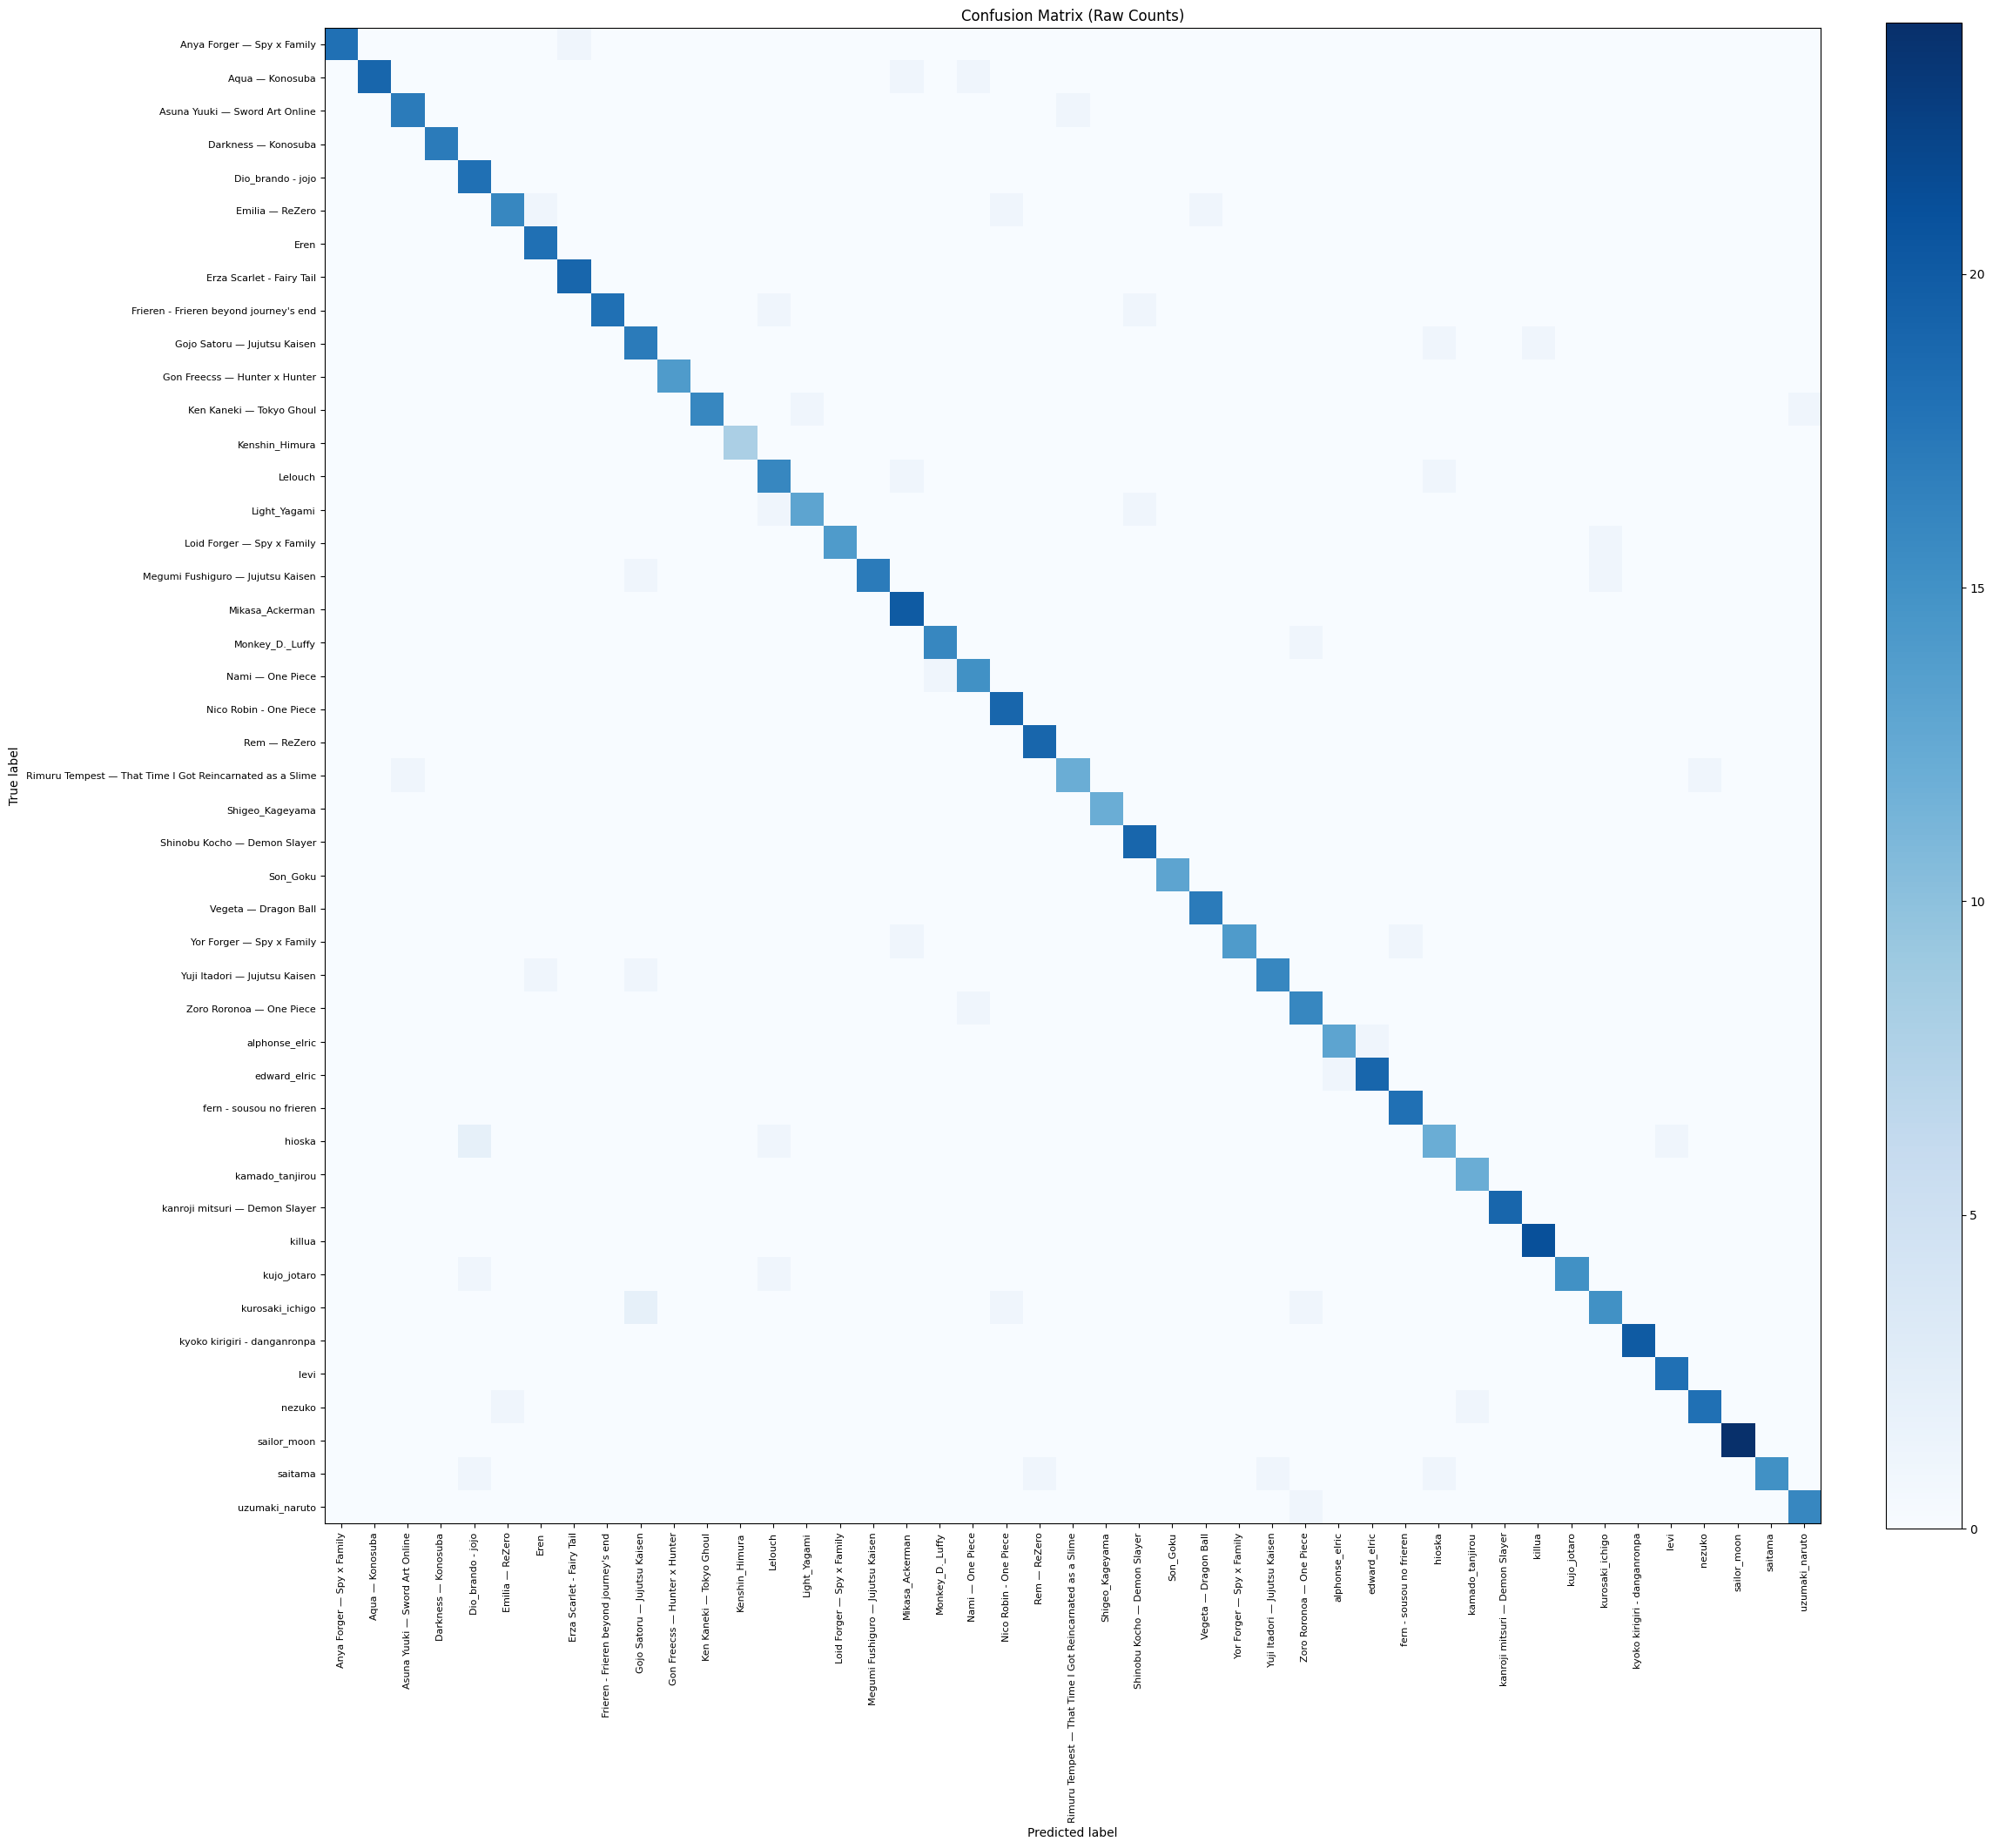

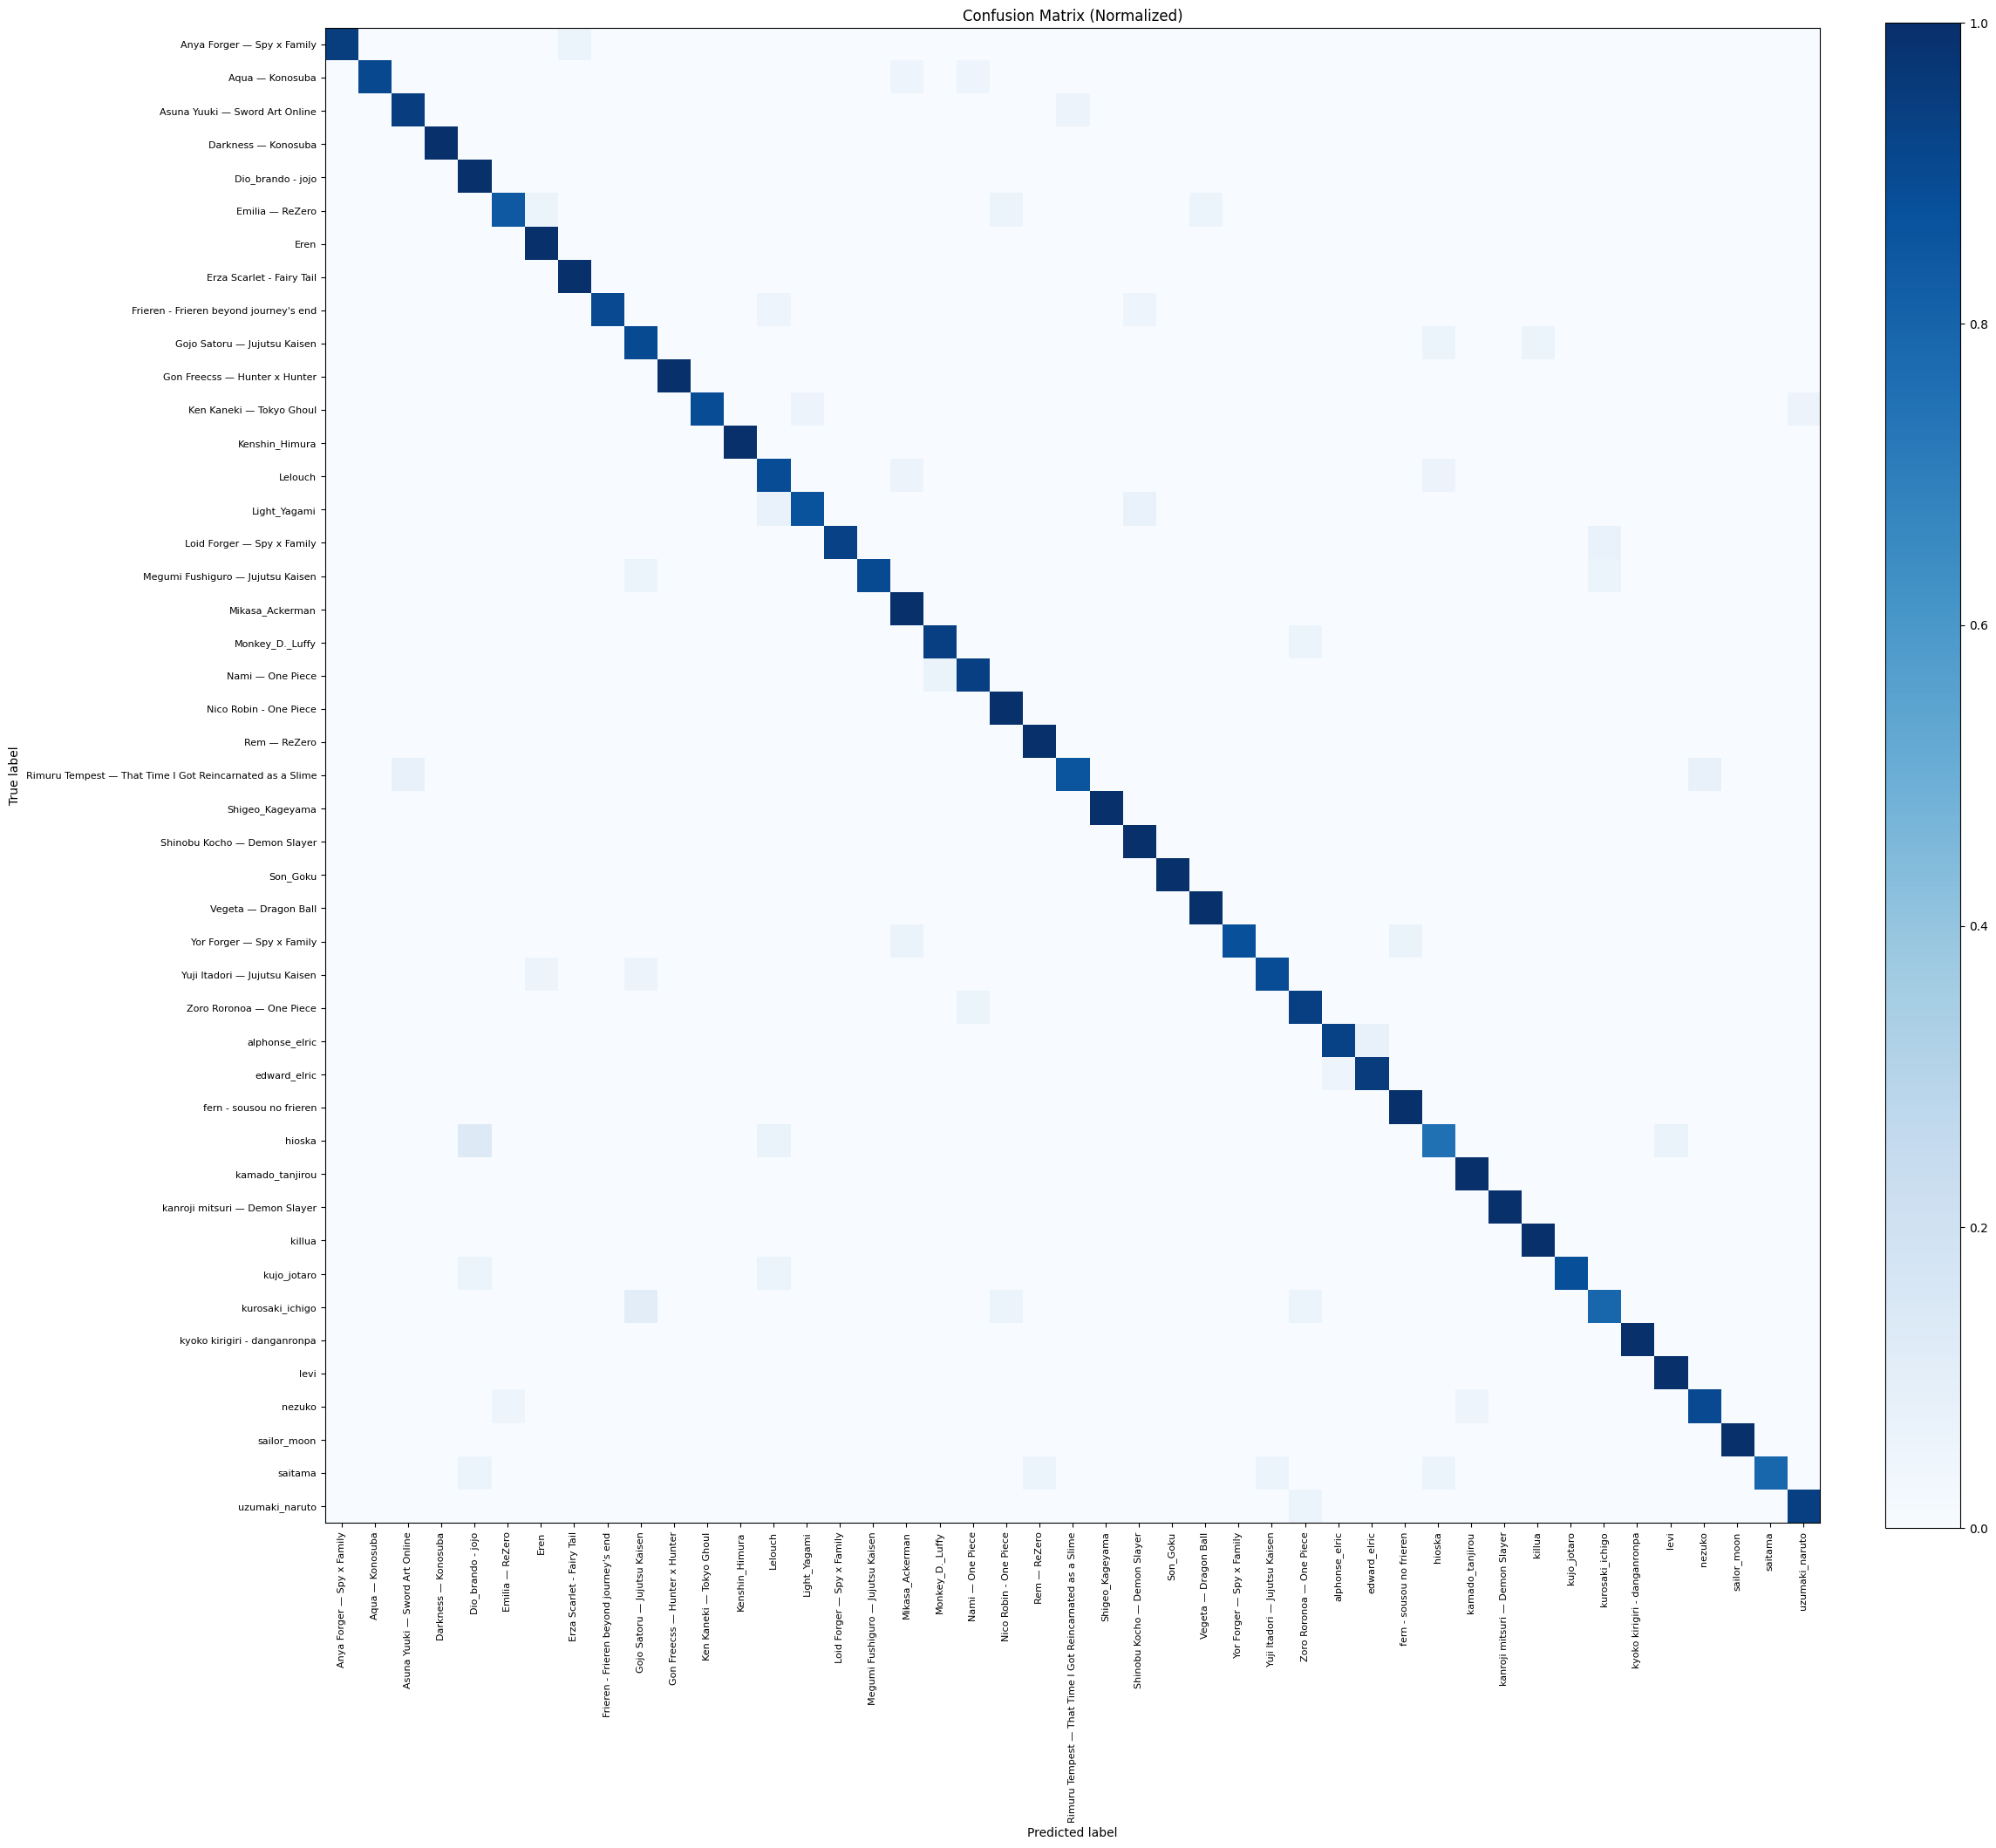

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, normalize=False, figsize=None, cmap='Blues', title=None):
    """
    Plot a confusion matrix for multi-class classification.

    Args:
        cm: confusion matrix as a 2D numpy array
        class_names: list of class names matching matrix order
        normalize: if True, display row-wise normalized values
        figsize: tuple like (width, height). If None, auto-sized by class count
        cmap: matplotlib colormap
        title: optional chart title
    """
    cm = np.asarray(cm)
    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError('cm must be a square 2D matrix.')
    if len(class_names) != cm.shape[0]:
        raise ValueError('class_names length must match confusion matrix size.')

    display_cm = cm.astype(float).copy()
    if normalize:
        row_sums = display_cm.sum(axis=1, keepdims=True)
        display_cm = np.divide(display_cm, row_sums, where=row_sums != 0)

    n_classes = len(class_names)
    if figsize is None:
        side = max(8, min(24, int(0.35 * n_classes) + 8))
        figsize = (side, side)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_cm, interpolation='nearest', cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(class_names, rotation=90, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

    if title is None:
        title = 'Confusion Matrix (Normalized)' if normalize else 'Confusion Matrix (Raw Counts)'
    ax.set_title(title)

    # Annotate only when class count is manageable to avoid clutter
    if n_classes <= 30:
        fmt = '.2f' if normalize else 'd'
        threshold = display_cm.max() / 2.0 if display_cm.size else 0
        for i in range(n_classes):
            for j in range(n_classes):
                val = display_cm[i, j]
                ax.text(
                    j, i, format(val, fmt),
                    ha='center', va='center',
                    color='white' if val > threshold else 'black',
                    fontsize=7
                )

    fig.tight_layout()
    return fig, ax


if 'metrics' in globals():
    # Raw counts
    plot_confusion_matrix(
        cm=metrics['confusion_matrix'],
        class_names=metrics['class_order'],
        normalize=False
    )
    plt.show()

    # Normalized (better for class imbalance)
    plot_confusion_matrix(
        cm=metrics['confusion_matrix'],
        class_names=metrics['class_order'],
        normalize=True
    )
    plt.show()
else:
    print("Run Cell 62 first to create 'metrics', then run this cell.")

Embedding

In [9]:
import torch
import torch.nn as nn
from transformers import AutoModelForImageClassification


def load_vit_for_embedding_gallery(model_pth_path, num_classes, device):
    """
    Loads a ViT backbone from a classification checkpoint, then
    removes the classification head entirely (replacing with Identity)
    to extract the raw, fine-tuned embeddings directly without retraining.

    Args:
        model_pth_path : path to the saved state_dict (model.pth)
        num_classes    : number of output classes used during classification training
        device         : torch device

    Returns:
        model with backbone weights loaded, outputting raw feature vectors.
    """
    model_name = "SmilingWolf/wd-vit-tagger-v3"
    backbone = AutoModelForImageClassification.from_pretrained(model_name)

    in_features = backbone.timm_model.head.in_features

    # Reconstruct classification head to match the saved weights structure
    backbone.timm_model.head = nn.Linear(in_features, num_classes)
    state_dict = torch.load(model_pth_path, map_location=device)
    backbone.load_state_dict(state_dict)
    print(f"Loaded classification weights from: {model_pth_path}")

    # Replace the head with Identity to just output the raw features (no retraining needed!)
    backbone.timm_model.head = nn.Identity()
    backbone.to(device)
    print(f"Embedding head removed. Model will output raw {in_features}-dimensional features.")
    return backbone


# ── Load model ────────────────────────────────────────────────────────────────
# Define device directly to prevent NameError
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_model = load_vit_for_embedding_gallery(
    model_pth_path="/content/drive/MyDrive/best_vit_model.pth", # Updated path
    num_classes=45,   # Hardcoded to 45 since train_dataset is not defined
    device=device
)

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loaded classification weights from: /content/drive/MyDrive/best_vit_model.pth
Embedding head removed. Model will output raw 768-dimensional features.


In [13]:
import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm


def build_embedding_index(
    model,
    image_folder,
    device,
    transform=None,
    extensions=(".jpg", ".jpeg", ".png"),
    batch_size=64,
):
    """
    Runs the fine-tuned embedding model over every image in each class
    subfolder and builds a per-class embedding gallery.

    Args:
        model        : fine-tuned embedding model (output is L2-normalised)
        image_folder : root folder, one subfolder per class
        device       : torch device
        transform    : torchvision transform; defaults to val_transform equivalent
        extensions   : image suffixes to consider
        batch_size   : images processed at once (tune to VRAM)

    Returns:
        embeddings : dict  { class_name: np.ndarray (N, embedding_dim) }
        index      : dict  { class_name: list of Path objects }
    """
    transform = val_transform or transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    root = Path(image_folder)
    embeddings = {}
    index      = {}

    model.eval()
    with torch.no_grad():
        for class_dir in tqdm(sorted(root.iterdir()), desc="Classes"):
            if not class_dir.is_dir():
                continue

            img_paths = sorted(
                p for p in class_dir.iterdir()
                if p.suffix.lower() in extensions
            )
            if not img_paths:
                continue

            class_embs = []
            # Process in batches
            for i in range(0, len(img_paths), batch_size):
                batch_paths = img_paths[i : i + batch_size]
                tensors = []
                for p in batch_paths:
                    try:
                        tensors.append(transform(Image.open(p).convert("RGB")))
                    except Exception:
                        continue

                if not tensors:
                    continue

                batch = torch.stack(tensors).to(device, non_blocking=True)
                out   = model(batch)
                embs  = F.normalize(out.logits, p=2, dim=1)
                class_embs.append(embs.cpu().numpy())

            if class_embs:
                embeddings[class_dir.name] = np.concatenate(class_embs, axis=0)
                index[class_dir.name]      = img_paths
                print(f"  {class_dir.name:30s}: {embeddings[class_dir.name].shape[0]} embeddings")

    total = sum(v.shape[0] for v in embeddings.values())
    print(f"\nTotal: {total} embeddings across {len(embeddings)} classes")
    return embeddings, index


# ── Extract ────────────────────────────────────────────────────────────────────
gallery_embeddings, gallery_index = build_embedding_index(
    model=embedding_model,
    image_folder="/content/drive/MyDrive/faces_split/train",
    device=device,
    transform=val_transform,
    batch_size=64,
)

# ── Save to disk ───────────────────────────────────────────────────────────────
# gallery_embeddings : { class_name -> np.ndarray (N, 128) }
# gallery_index      : { class_name -> [Path, ...] }
import pickle, numpy as np

np.save("/content/drive/MyDrive/gallery_embeddings.npy", gallery_embeddings)   # dict of arrays

with open("/content/drive/MyDrive/gallery_index.pkl", "wb") as f:
    pickle.dump(gallery_index, f)

print("Saved gallery_embeddings.npy and gallery_index.pkl to Google Drive")

Classes:   0%|          | 0/45 [00:00<?, ?it/s]

  Anya Forger — Spy x Family    : 149 embeddings
  Aqua — Konosuba               : 145 embeddings
  Asuna Yuuki — Sword Art Online: 143 embeddings
  Darkness — Konosuba           : 146 embeddings
  Dio_brando - jojo             : 142 embeddings
  Emilia — ReZero               : 149 embeddings
  Eren                          : 153 embeddings
  Erza Scarlet - Fairy Tail     : 148 embeddings
  Frieren - Frieren beyond journey's end: 144 embeddings
  Gojo Satoru — Jujutsu Kaisen  : 146 embeddings
  Gon Freecss — Hunter x Hunter : 121 embeddings
  Ken Kaneki — Tokyo Ghoul      : 148 embeddings
  Kenshin_Himura                : 68 embeddings
  Lelouch                       : 141 embeddings
  Light_Yagami                  : 139 embeddings
  Loid Forger — Spy x Family    : 127 embeddings
  Megumi Fushiguro — Jujutsu Kaisen: 124 embeddings
  Mikasa_Ackerman               : 154 embeddings
  Monkey_D._Luffy               : 148 embeddings
  Nami — One Piece              : 137 embeddings
  Nico Rob

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (136257220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  sailor_moon                   : 167 embeddings
  saitama                       : 112 embeddings
  uzumaki_naruto                : 151 embeddings

Total: 6219 embeddings across 45 classes
Saved gallery_embeddings.npy and gallery_index.pkl to Google Drive


In [14]:
import numpy as np
import pickle

# ── Compute one centroid embedding per class ───────────────────────────────────
# gallery_embeddings: { class_name -> np.ndarray(N, 128) }  (already L2-normalised per image)
# class_centroids  : { class_name -> np.ndarray(128,) }     (mean, then re-normalised)

class_centroids = {}
for class_name, embs in gallery_embeddings.items():
    mean_emb = embs.mean(axis=0)
    # Re-normalise so dot product == cosine similarity at query time
    mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-8)
    class_centroids[class_name] = mean_emb

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"{'Class':<35} {'Images':>6}  {'Centroid shape'}")
print("-" * 60)
for cls in sorted(class_centroids):
    n_imgs = gallery_embeddings[cls].shape[0]
    print(f"{cls:<35} {n_imgs:>6}  {class_centroids[cls].shape}")

print(f"\nTotal classes: {len(class_centroids)}")
print(f"Embedding dim : {next(iter(class_centroids.values())).shape[0]}")

# ── Stack into a matrix for fast retrieval ─────────────────────────────────────
# centroid_matrix[i] is the centroid of class_names[i]
class_names      = sorted(class_centroids.keys())
centroid_matrix  = np.stack([class_centroids[c] for c in class_names])  # (num_classes, 128)
print(f"\nCentroid matrix shape: {centroid_matrix.shape}")

# ── Save ───────────────────────────────────────────────────────────────────────
np.save("/content/drive/MyDrive/class_centroids.npy", centroid_matrix)

with open("/content/drive/MyDrive/class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

print("Saved  class_centroids.npy  and  class_names.pkl to Google Drive")

Class                               Images  Centroid shape
------------------------------------------------------------
Anya Forger — Spy x Family             149  (768,)
Aqua — Konosuba                        145  (768,)
Asuna Yuuki — Sword Art Online         143  (768,)
Darkness — Konosuba                    146  (768,)
Dio_brando - jojo                      142  (768,)
Emilia — ReZero                        149  (768,)
Eren                                   153  (768,)
Erza Scarlet - Fairy Tail              148  (768,)
Frieren - Frieren beyond journey's end    144  (768,)
Gojo Satoru — Jujutsu Kaisen           146  (768,)
Gon Freecss — Hunter x Hunter          121  (768,)
Ken Kaneki — Tokyo Ghoul               148  (768,)
Kenshin_Himura                          68  (768,)
Lelouch                                141  (768,)
Light_Yagami                           139  (768,)
Loid Forger — Spy x Family             127  (768,)
Megumi Fushiguro — Jujutsu Kaisen      124  (768,)
Mikasa_Ack

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_class_embeddings(
    gallery_embeddings,
    class_centroids=None,
    selected_classes=None,
    mode="centroids",
    method="tsne",
    max_points_per_class=100,
    perplexity=10,
    random_state=42,
    figsize=(12, 10),
):
    """
    Visualize class embeddings in 2D using PCA or t-SNE.

    Args:
        gallery_embeddings: dict {class_name: np.ndarray(N, D)}
        class_centroids: optional dict {class_name: np.ndarray(D,)}
        selected_classes: optional list of class names to visualize
        mode:
            - "centroids": plot one point per class centroid
            - "images": plot per-image embeddings for each class
        method:
            - "tsne": nonlinear 2D projection, usually better for cluster visualization
            - "pca": faster linear projection
        max_points_per_class: max number of image embeddings per class in images mode
        perplexity: t-SNE perplexity value
        random_state: reproducibility for t-SNE
        figsize: matplotlib figure size
    """
    if selected_classes is None:
        selected_classes = sorted(gallery_embeddings.keys())

    selected_classes = [cls for cls in selected_classes if cls in gallery_embeddings]
    if not selected_classes:
        raise ValueError("No valid classes found in gallery_embeddings.")

    features = []
    labels = []

    if mode == "centroids":
        if class_centroids is None:
            class_centroids = {}
            for cls in selected_classes:
                mean_emb = gallery_embeddings[cls].mean(axis=0)
                mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-8)
                class_centroids[cls] = mean_emb

        for cls in selected_classes:
            features.append(class_centroids[cls])
            labels.append(cls)

    elif mode == "images":
        for cls in selected_classes:
            embs = gallery_embeddings[cls]
            if len(embs) > max_points_per_class:
                sample_idx = np.random.choice(len(embs), max_points_per_class, replace=False)
                embs = embs[sample_idx]

            for emb in embs:
                features.append(emb)
                labels.append(cls)
    else:
        raise ValueError("mode must be 'centroids' or 'images'.")

    X = np.stack(features)

    if method == "tsne":
        # t-SNE works best when perplexity is smaller than the number of samples.
        effective_perplexity = min(perplexity, max(2, len(X) - 1))
        X_2d = TSNE(
            n_components=2,
            perplexity=effective_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state,
        ).fit_transform(X)
    elif method == "pca":
        X_centered = X - X.mean(axis=0, keepdims=True)
        _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
        X_2d = X_centered @ vt[:2].T
    else:
        raise ValueError("method must be 'tsne' or 'pca'.")

    plt.figure(figsize=figsize)
    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap("tab20", len(unique_labels))

    for idx, cls in enumerate(unique_labels):
        mask = np.array(labels) == cls
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=90 if mode == "centroids" else 28,
            alpha=0.9 if mode == "centroids" else 0.65,
            color=cmap(idx),
            label=cls,
        )

    if mode == "centroids":
        for i, cls in enumerate(labels):
            plt.text(X_2d[i, 0], X_2d[i, 1], cls, fontsize=9)

    plt.title(f"Embedding visualization ({mode}, {method})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True, alpha=0.25)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()




/tmp/ipykernel_1703/209886584.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


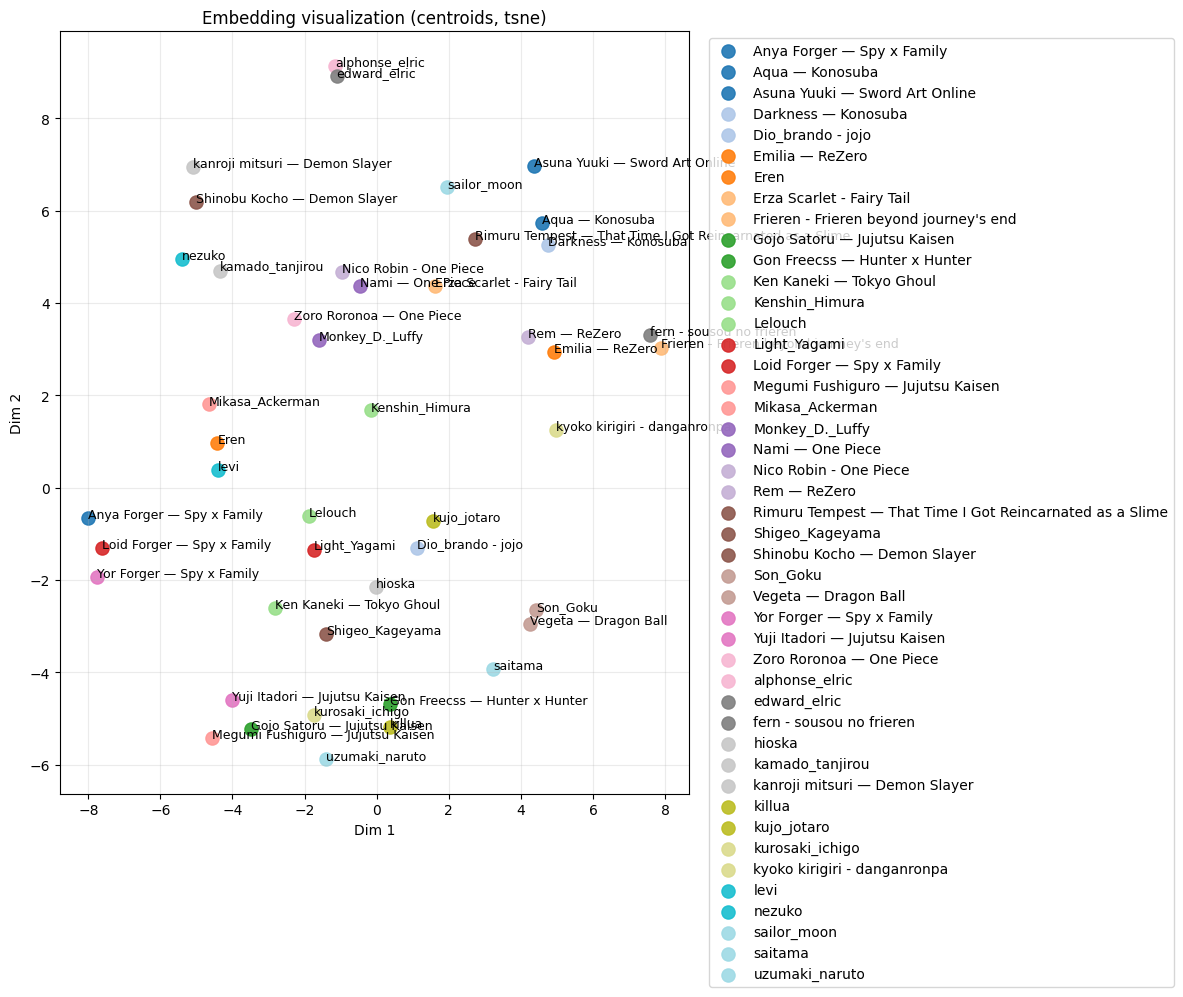

/tmp/ipykernel_1703/209886584.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


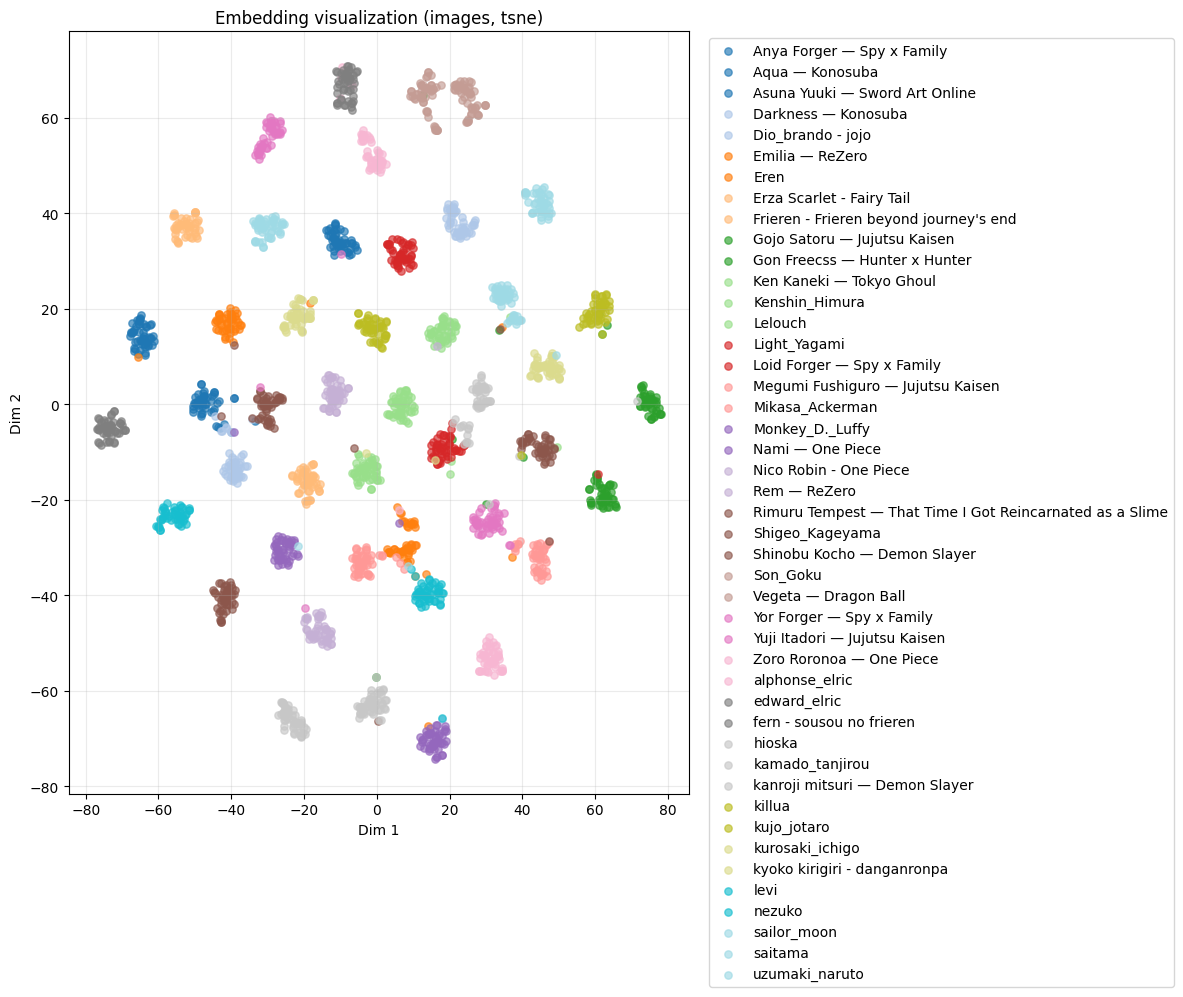

In [18]:
# Visualize class centroids with t-SNE for all classes
visualize_class_embeddings(
    gallery_embeddings=gallery_embeddings,
    class_centroids=class_centroids,
    selected_classes=class_names,
    mode="centroids",
    method="tsne",
    perplexity=15 # Adjusted perplexity for 45 classes
)

# Visualize per-image embeddings for a subset of 10 classes
visualize_class_embeddings(
    gallery_embeddings=gallery_embeddings,
    selected_classes=class_names[:],
    mode="images",
    method="tsne",
    max_points_per_class=50,
    perplexity=10,
)

Total classes: 45
Known classes: 36
Unknown classes: 9

=== OPEN-SET RECOGNITION METRICS ===
Rank-1 Accuracy (Knowns): 97.80%
AUROC:                    0.9882
Equal Error Rate (EER):   4.41%
Optimal Threshold (τ):    0.6572
Unknown Rejection Rate:   95.59%
False Acceptance Rate:    4.41%
False Rejection Rate:     4.39%



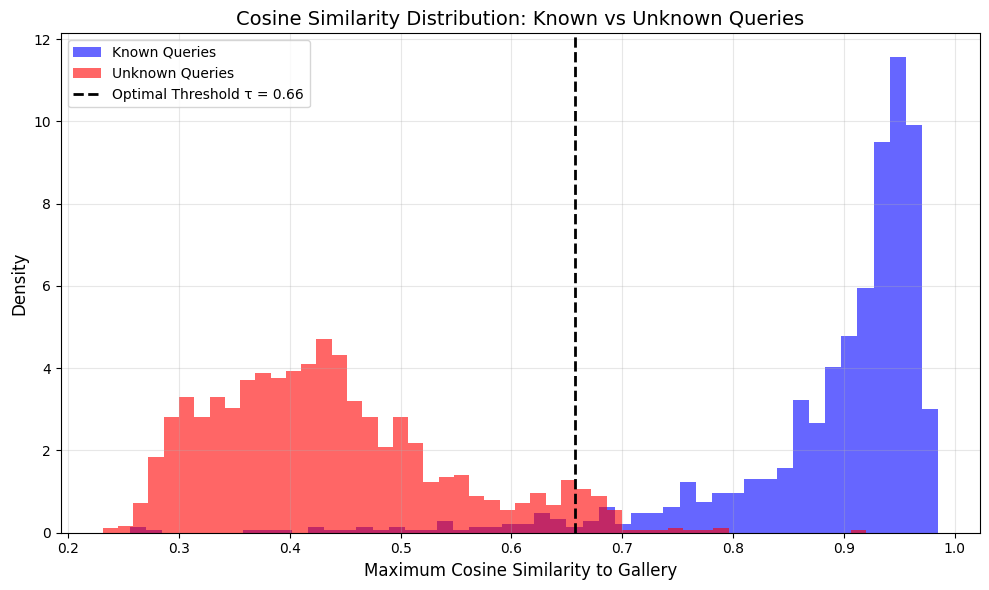

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import random

def evaluate_open_set_recognition(gallery_embeddings, num_known=36, test_size=0.2, random_state=42):
    """
    Evaluates open-set recognition performance using pre-extracted embeddings.

    Args:
        gallery_embeddings (dict): Dictionary mapping class names to numpy arrays of shape (N, D).
        num_known (int): Number of classes to treat as 'Known'.
        test_size (float): Proportion of known class images to use as queries (rest is gallery).
        random_state (int): Random seed for reproducibility.
    """
    # 1. Split classes into Known (36) and Unknown (9)
    all_classes = sorted(list(gallery_embeddings.keys()))
    random.seed(random_state)
    random.shuffle(all_classes)

    known_classes = all_classes[:num_known]
    unknown_classes = all_classes[num_known:]

    print(f"Total classes: {len(all_classes)}")
    print(f"Known classes: {len(known_classes)}")
    print(f"Unknown classes: {len(unknown_classes)}\n")

    # 2. Split data: Build Gallery and Query sets
    gallery_embs_dict = {}
    query_known_embs = []
    query_known_labels = []

    query_unknown_embs = []
    query_unknown_labels = []

    for cls in known_classes:
        embs = gallery_embeddings[cls]
        # Split known embeddings into Gallery and Query sets
        X_gal, X_query = train_test_split(embs, test_size=test_size, random_state=random_state)
        gallery_embs_dict[cls] = X_gal
        query_known_embs.append(X_query)
        query_known_labels.extend([cls] * len(X_query))

    query_known_embs = np.vstack(query_known_embs)

    for cls in unknown_classes:
        embs = gallery_embeddings[cls]
        # All unknown embeddings are used as queries
        query_unknown_embs.append(embs)
        query_unknown_labels.extend([cls] * len(embs))

    query_unknown_embs = np.vstack(query_unknown_embs)

    # 3. Build the Gallery (Mean Pooling)
    gallery_centroids = {}
    for cls, embs in gallery_embs_dict.items():
        mean_emb = embs.mean(axis=0)
        mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-8) # L2 Normalize
        gallery_centroids[cls] = mean_emb

    centroid_matrix = np.stack([gallery_centroids[c] for c in known_classes])

    # 4. Query the Gallery (Cosine Similarity)
    # Known Queries
    sim_known = query_known_embs @ centroid_matrix.T
    max_sim_known = sim_known.max(axis=1)
    pred_idx_known = sim_known.argmax(axis=1)
    pred_labels_known = [known_classes[i] for i in pred_idx_known]

    # Unknown Queries
    sim_unknown = query_unknown_embs @ centroid_matrix.T
    max_sim_unknown = sim_unknown.max(axis=1)

    # 5. Compute Metrics
    # Rank-1 Accuracy for Known Classes
    correct_known = sum([1 for p, t in zip(pred_labels_known, query_known_labels) if p == t])
    rank1_acc = correct_known / len(query_known_labels)

    # Binary classification for AUROC: 1 = Known, 0 = Unknown
    y_true = np.array([1] * len(max_sim_known) + [0] * len(max_sim_unknown))
    y_scores = np.concatenate([max_sim_known, max_sim_unknown])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Calculate Equal Error Rate (EER) and Optimal Threshold
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    optimal_threshold = thresholds[eer_idx]
    eer = fpr[eer_idx]

    # Calculate Rejection Rates at Optimal Threshold
    # Unknown Rejection Rate (URR) = True Negative Rate
    urr = np.sum(max_sim_unknown < optimal_threshold) / len(max_sim_unknown)
    # False Acceptance Rate (FAR) = False Positive Rate (Unknowns classified as Known)
    far = np.sum(max_sim_unknown >= optimal_threshold) / len(max_sim_unknown)
    # False Rejection Rate (FRR) = Knowns classified as Unknown
    frr = np.sum(max_sim_known < optimal_threshold) / len(max_sim_known)

    print("=== OPEN-SET RECOGNITION METRICS ===")
    print(f"Rank-1 Accuracy (Knowns): {rank1_acc:.2%}")
    print(f"AUROC:                    {roc_auc:.4f}")
    print(f"Equal Error Rate (EER):   {eer:.2%}")
    print(f"Optimal Threshold (τ):    {optimal_threshold:.4f}")
    print(f"Unknown Rejection Rate:   {urr:.2%}")
    print(f"False Acceptance Rate:    {far:.2%}")
    print(f"False Rejection Rate:     {frr:.2%}")
    print("====================================\n")

    # 6. Visualize Distributions
    plt.figure(figsize=(10, 6))
    plt.hist(max_sim_known, bins=50, alpha=0.6, label='Known Queries', color='blue', density=True)
    plt.hist(max_sim_unknown, bins=50, alpha=0.6, label='Unknown Queries', color='red', density=True)
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2,
                label=f'Optimal Threshold τ = {optimal_threshold:.2f}')

    plt.title('Cosine Similarity Distribution: Known vs Unknown Queries', fontsize=14)
    plt.xlabel('Maximum Cosine Similarity to Gallery', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the evaluation using the gallery_embeddings already in memory
evaluate_open_set_recognition(gallery_embeddings, num_known=36, test_size=0.2)